### **Libraries Import**

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

### **Define Input and Output Folder Paths**

In [2]:
# Paths
input_folder = './input'
labels_folder = './output'

### **Load and Prepare Image Dataset**

In [3]:
# Get sorted list of .jpg files
image_paths = [
    os.path.join(input_folder, f)
    for f in sorted(os.listdir(input_folder))
    if f.lower().endswith('.jpg')
]
print(f"Total input images found: {len(image_paths)}")

Total input images found: 23


In [4]:
images = []
labels = []

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is not None:
        images.append(img)

        # Load label from matching .txt file
        filename = os.path.splitext(os.path.basename(img_path))[0]
        label_file = os.path.join(labels_folder, filename.replace("input", "output") + ".txt")
        if os.path.exists(label_file):
            with open(label_file, "r") as f:
                labels.append(f.read().strip())
        else:
            labels.append(None)
    else:
        print(f"Failed to load image: {img_path}")

print(f"Successfully loaded {len(images)} images with {len(labels)} labels.")

Successfully loaded 23 images with 23 labels.


### **Apply Otsu's Thresholding**


In [5]:
# Threshold images using Otsu's method
thresholded_images = []
for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    thresholded_images.append(thresh)

print(f"Applied Otsu threshold to {len(thresholded_images)} images.")

Applied Otsu threshold to 23 images.


### **Visualize Thresholded Images with Histograms**


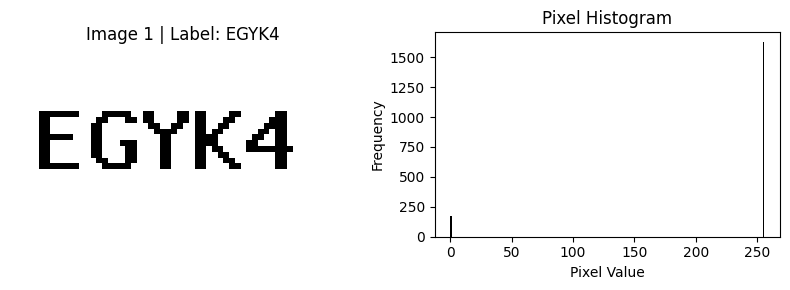

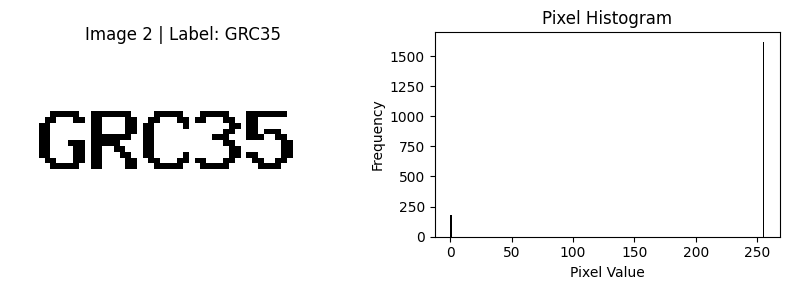

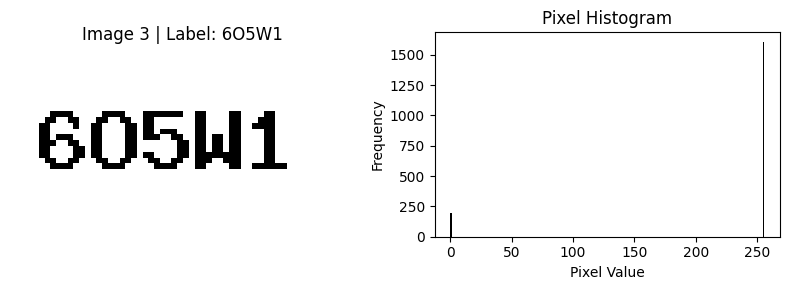

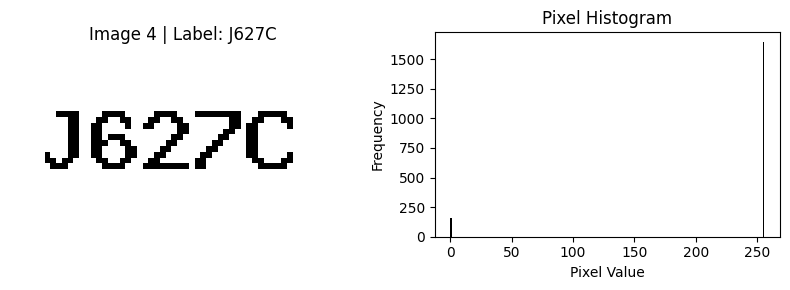

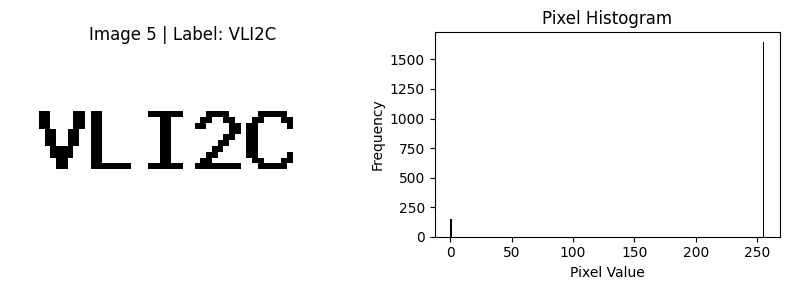

In [6]:
# Show image + histogram side-by-side for first 5
for i in range(5):
    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(thresholded_images[i], cmap='gray')
    plt.title(f"Image {i+1} | Label: {labels[i]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.hist(thresholded_images[i].ravel(), bins=256, range=(0, 256), color='black')
    plt.title("Pixel Histogram")
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

### **Character Segmentation Function**


In [7]:
def segment_characters_from_binary(binary_img):
    """Segment characters in a binary captcha image by horizontal projection."""
    # Check if strictly binary
    if not np.isin(binary_img, [0, 255]).all():
        print("Image is not strictly binary")
        return []

    inverted = 255 - binary_img  # text white, background black
    projection = np.sum(inverted, axis=0)
    threshold = 0  # pixel sum threshold

    segments = []
    in_char = False
    start = 0
    for i, val in enumerate(projection):
        if val > threshold and not in_char:
            start = i
            in_char = True
        elif val <= threshold and in_char:
            end = i
            in_char = False
            segments.append((start, end))
    if in_char:
        segments.append((start, len(projection)))
    return segments

### **Build Segmented Character Dataset**


In [8]:
# Store segmented characters and labels
segmented_dataset = []  # List of (char_image, char_label)

for thresh_img, full_label in zip(thresholded_images, labels):
    if full_label is None:
        continue  # Skip if no label file

    # Get character boundaries using your function
    char_segments = segment_characters_from_binary(thresh_img)

    # Crop each segment and pair with corresponding label char
    for (start, end), char_label in zip(char_segments, full_label):
        char_img = thresh_img[:, start:end]
        segmented_dataset.append((char_img, char_label))

print(f"Total segmented characters: {len(segmented_dataset)}")

Total segmented characters: 115


### **Preview Segmented Characters**


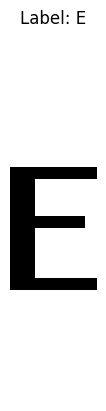

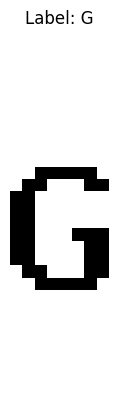

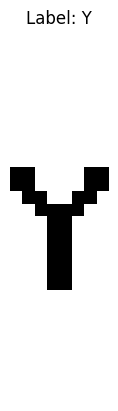

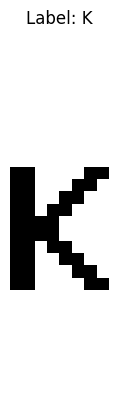

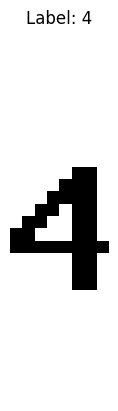

In [9]:
# Example: visualize first 5 characters
for i in range(5):
    img, lbl = segmented_dataset[i]
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {lbl}")
    plt.axis('off')
    plt.show()

### **Train Neural Network Model**


In [10]:
# ----------------------------
# ANN training using segmented_dataset
# segmented_dataset is list of (char_img, char_label)
# ----------------------------


# Safety check
if len(segmented_dataset) == 0:
    raise ValueError("segmented_dataset is empty. Run segmentation first.")

# Parameters
IMG_H, IMG_W = 28, 28
EPOCHS = 25
BATCH_SIZE = 16
VAL_SPLIT = 0.1
RANDOM_SEED = 42

# Prepare X and y lists
X_list = []
y_list = []

for char_img, char_label in segmented_dataset:
    # ensure grayscale numpy array
    arr = char_img.copy()
    # if binary (0/255) -> convert to 0/1 float after resizing
    try:
        arr_resized = cv2.resize(arr, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    except Exception as e:
        # fallback: skip problematic image
        print("Skipping a char due to resize error:", e)
        continue

    X_list.append(arr_resized.astype('float32'))
    y_list.append(str(char_label))  # ensure string labels

X = np.array(X_list)  # shape (N, H, W)
X = X.reshape(-1, IMG_H, IMG_W, 1) / 255.0  # normalize to 0-1 and add channel

# Build mapping from label -> integer
unique_labels = sorted(list(set(y_list)))
label_to_int = {lab: i for i, lab in enumerate(unique_labels)}
int_to_label = {i: lab for lab, i in label_to_int.items()}

y_int = np.array([label_to_int[lab] for lab in y_list], dtype=np.int32)
y_cat = to_categorical(y_int, num_classes=len(unique_labels))

print(f"Total chars: {X.shape[0]} | Classes: {len(unique_labels)} -> {unique_labels}")

# Shuffle + split (numpy-based)
rng = np.random.default_rng(RANDOM_SEED)
indices = np.arange(X.shape[0])
rng.shuffle(indices)

X = X[indices]
y_cat = y_cat[indices]

split_at = int(X.shape[0] * (1 - VAL_SPLIT))
X_train, X_val = X[:split_at], X[split_at:]
y_train, y_val = y_cat[:split_at], y_cat[split_at:]

print(f"Train samples: {X_train.shape[0]} | Val samples: {X_val.shape[0]}")

from tensorflow.keras.layers import Conv2D, MaxPooling2D

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_H, IMG_W, 1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(unique_labels), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


# Evaluate
loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation loss: {loss:.4f} | Validation accuracy: {acc:.4f}")

# Quick prediction helper example (predict first 5 val samples)
preds = model.predict(X_val[:5])
for i, p in enumerate(preds):
    pred_idx = np.argmax(p)
    true_idx = np.argmax(y_val[i])
    print(f"Sample {i}: True={int_to_label[true_idx]} Pred={int_to_label[pred_idx]} (conf={p[pred_idx]:.3f})")


Total chars: 115 | Classes: 35 -> ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Train samples: 103 | Val samples: 12


c:\Users\miana\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,259 (891.64 KB)

 Trainable params: 228,259 (891.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
7/7 - 2s - 284ms/step - accuracy: 0.0000e+00 - loss: 3.5875 - val_accuracy: 0.0000e+00 - val_loss: 3.5533
Epoch 2/25
7/7 - 2s - 284ms/step - accuracy: 0.0000e+00 - loss: 3.5875 - val_accuracy: 0.0000e+00 - val_loss: 3.5533
Epoch 2/25
7/7 - 0s - 19ms/step - accuracy: 0.0680 - loss: 3.4952 - val_accuracy: 0.0000e+00 - val_loss: 3.5817
Epoch 3/25
7/7 - 0s - 19ms/step - accuracy: 0.0680 - loss: 3.4952 - val_accuracy: 0.0000e+00 - val_loss: 3.5817
Epoch 3/25
7/7 - 0s - 27ms/step - accuracy: 0.0971 - loss: 3.4328 - val_accuracy: 0.0833 - val_loss: 3.6185
Epoch 4/25
7/7 - 0s - 27ms/step - accuracy: 0.0971 - loss: 3.4328 - val_accuracy: 0.0833 - val_loss: 3.6185
Epoch 4/25
7/7 - 0s - 23ms/step - accuracy: 0.1165 - loss: 3.3578 - val_accuracy: 0.2500 - val_loss: 3.5807
Epoch 5/25
7/7 - 0s - 23ms/step - accuracy: 0.1165 - loss: 3.3578 - val_accuracy: 0.2500 - val_loss: 3.5807
Epoch 5/25
7/7 - 0s - 22ms/step - accuracy: 0.1650 - loss: 3.2353 - val_accuracy: 0.2500 - val_loss: 3.6661
Ep

### **Visualize Training History**


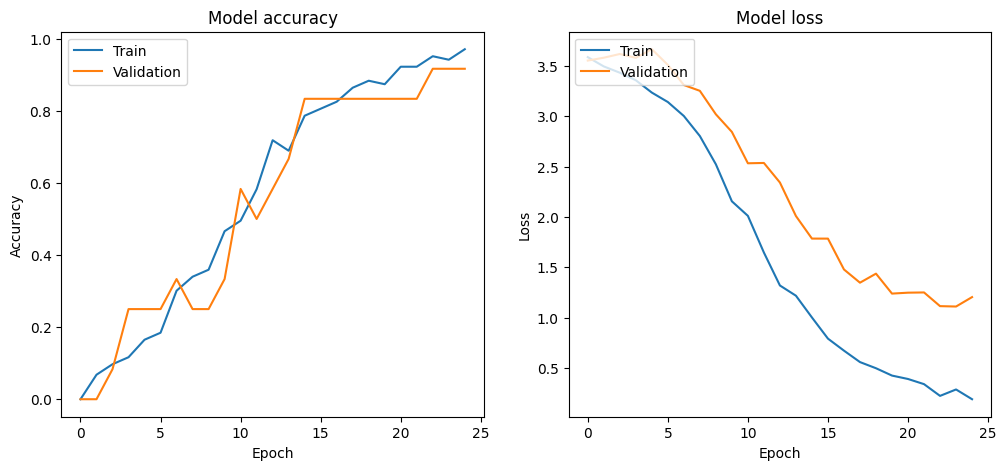

In [11]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### **Test Model on New Images**


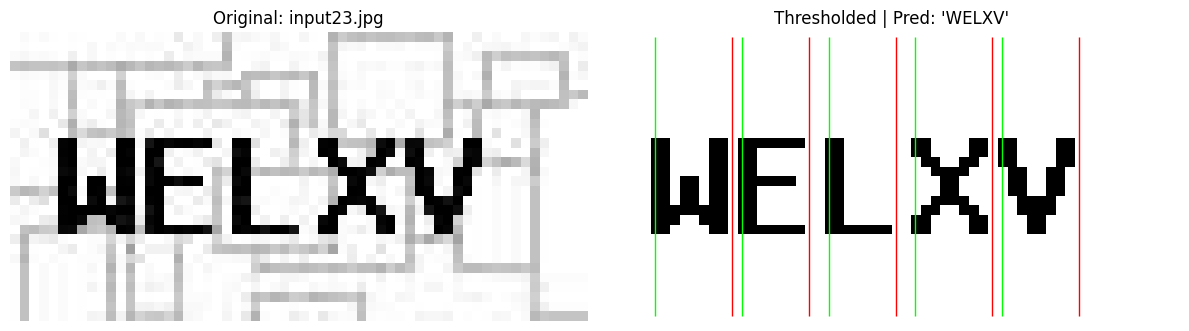

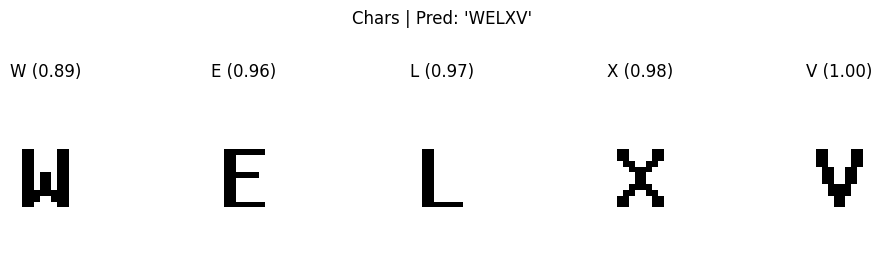

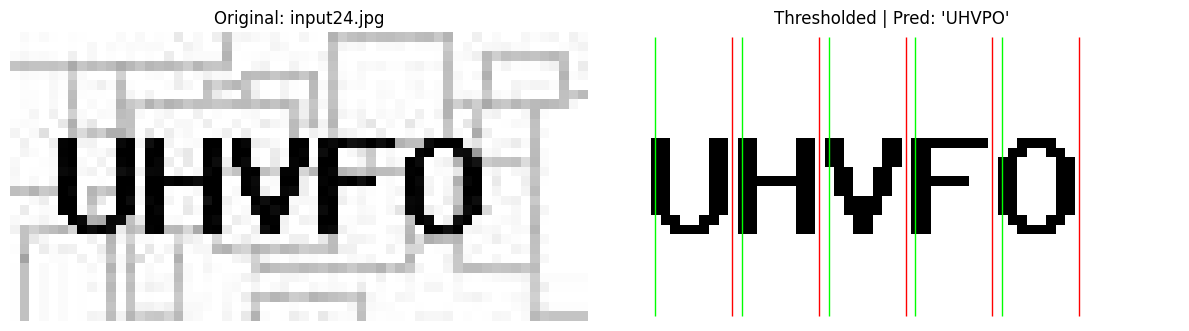

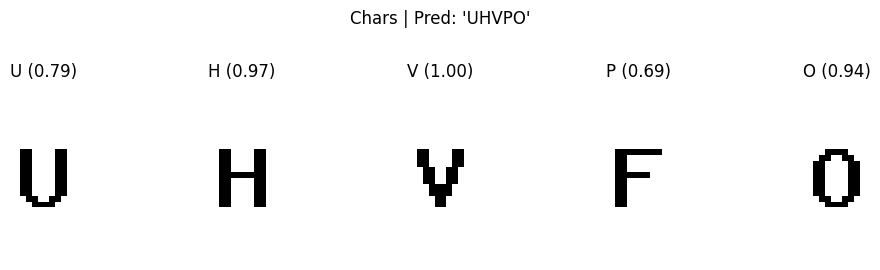

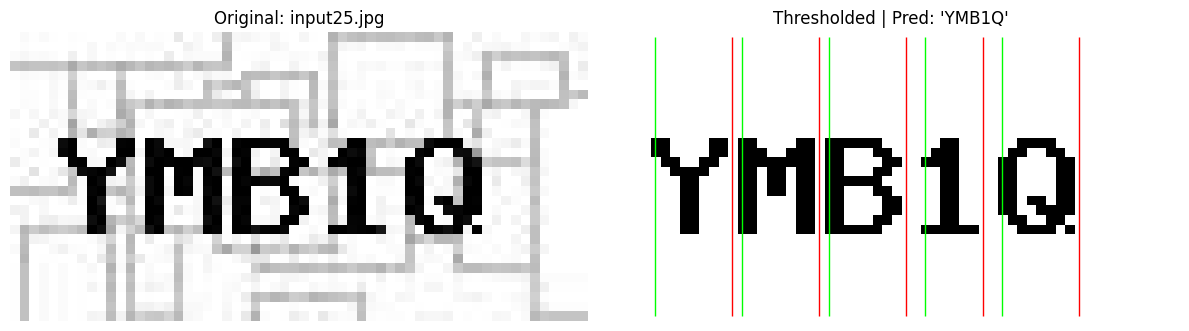

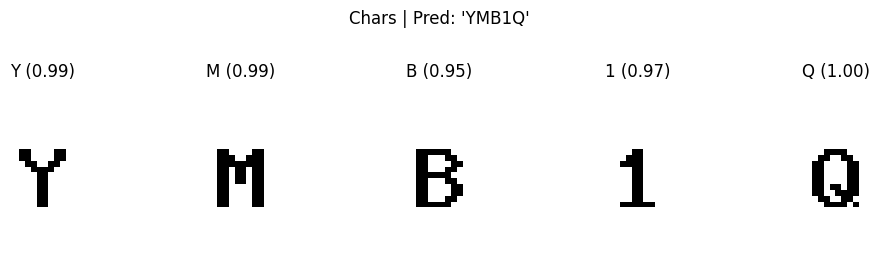

In [12]:
# Visualize predictions on Test_X images


# Safety checks
if 'model' not in globals() or 'int_to_label' not in globals():
    raise RuntimeError("Model or label mapping not found. Run training/inference cells first.")

try:
    IMG_H, IMG_W
except NameError:
    IMG_H, IMG_W = 28, 28

TEST_INPUT_DIR = './Test_X'
exts = ('.jpg', '.jpeg', '.png', '.bmp')

def _predict_chars_from_thresh(thresh_img):
    segments = segment_characters_from_binary(thresh_img)
    if len(segments) == 0:
        return "", [], []

    batch, spans = [], []
    for start, end in segments:
        ch = thresh_img[:, start:end]
        try:
            ch_resized = cv2.resize(ch, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
        except Exception:
            continue
        batch.append(ch_resized.astype('float32'))
        spans.append((start, end))

    if len(batch) == 0:
        return "", [], []

    Xb = np.stack(batch, axis=0).reshape(-1, IMG_H, IMG_W, 1) / 255.0
    preds = model.predict(Xb, verbose=0)
    idxs = np.argmax(preds, axis=1)
    labels = [int_to_label[int(i)] for i in idxs]
    confs = preds[np.arange(len(idxs)), idxs]
    return "".join(labels), spans, list(zip(labels, confs))

def visualize_test_images(max_images=6):
    if not os.path.exists(TEST_INPUT_DIR):
        raise FileNotFoundError(f"Test input folder not found: {TEST_INPUT_DIR}")

    test_image_paths = [
        os.path.join(TEST_INPUT_DIR, f)
        for f in sorted(os.listdir(TEST_INPUT_DIR))
        if f.lower().endswith(exts)
    ]
    if len(test_image_paths) == 0:
        print("No test images found.")
        return

    for img_path in test_image_paths[:max_images]:
        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Could not read image: {img_path}")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        pred_text, spans, char_preds = _predict_chars_from_thresh(thresh)

        # Figure 1: Original + Thresholded with segment lines
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {os.path.basename(img_path)}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(thresh, cmap='gray')
        ax = plt.gca()
        for start, end in spans:
            ax.vlines([start, end], ymin=0, ymax=thresh.shape[0]-1, colors=['lime', 'red'], linewidth=1)
        plt.title(f"Thresholded | Pred: '{pred_text}'")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        # Figure 2: Character crops with label and confidence
        if len(char_preds) > 0:
            cols = min(8, len(char_preds))
            rows = int(np.ceil(len(char_preds) / cols))
            plt.figure(figsize=(2.2*cols, 2.6*rows))
            for i, ((label, conf), (start, end)) in enumerate(zip(char_preds, spans)):
                ch = thresh[:, start:end]
                plt.subplot(rows, cols, i+1)
                plt.imshow(ch, cmap='gray')
                plt.title(f"{label} ({conf:.2f})")
                plt.axis('off')
            plt.suptitle(f"Chars | Pred: '{pred_text}'", y=1.02)
            plt.tight_layout()
            plt.show()
        else:
            print("No segments found or usable for this image.")

# Run visualization for a few samples
visualize_test_images(max_images=6)